In [2]:
# import marimo as mo
import torch
import os 
import pickle
import io

# text stuff
from sentence_transformers import SentenceTransformer
from sentence_transformers.models import StaticEmbedding
from sentence_transformers import util
from tokenizers import Tokenizer

# mathy stuff
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# plotting stuff 
import matplotlib.pyplot as plt
import seaborn as sns

# setting directory
os.chdir("/teamspace/studios/this_studio/mapping_reform")

In [3]:
class CPUUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else:
            return super().find_class(module, name)

# initialising empty dict to store
publication_data = {}

# reading in publication vector pickle files 
for filename in os.listdir("data/pub_embeddings_norm_mpnet_v2/"):
    filepath = os.path.join("data/pub_embeddings_norm_mpnet_v2/", filename)
    print(f"Loading data for {filepath}...")
    with open(filepath, "rb") as f:
        data = CPUUnpickler(f).load()
        publication_data[filename] = data

Loading data for data/pub_embeddings_norm_mpnet_v2/the_english_womans_journal.pkl...
Loading data for data/pub_embeddings_norm_mpnet_v2/the_leader.pkl...
Loading data for data/pub_embeddings_norm_mpnet_v2/the_monthly_repository.pkl...
Loading data for data/pub_embeddings_norm_mpnet_v2/the_northern_star.pkl...
Loading data for data/pub_embeddings_norm_mpnet_v2/the_publishers_circular.pkl...
Loading data for data/pub_embeddings_norm_mpnet_v2/the_tomahawk.pkl...


In [3]:
# checking content of each dict
publication_data['the_northern_star.pkl'].keys()

dict_keys(['articles', 'dates', 'embeddings'])

In [4]:
# Prepare lists to hold everything
all_articles = []
all_embeddings = []
all_dates = []
all_sources = []

# loading everything into one structure
for name, pubdata in {
    'ewj': publication_data["the_english_womans_journal.pkl"],
    'star': publication_data["the_northern_star.pkl"],
    'leader': publication_data["the_leader.pkl"],
    'circ': publication_data['the_publishers_circular.pkl'],
    'tomahawk': publication_data['the_tomahawk.pkl'],
    'repo': publication_data['the_monthly_repository.pkl']
}.items():
    all_articles.extend(pubdata['articles'])
    all_embeddings.extend(pubdata['embeddings'])
    all_dates.extend(pubdata['dates'])
    all_sources.extend([name] * len(pubdata['articles']))

In [5]:
# # extracting 'embeddings' key from the article/embeddings dictionary
# ewj_embeddings = ewj_data['embeddings']
# # leader_embeddings = leader_data['embeddings']

In [6]:
# # checking that the content is what i want
# print(ewj_data.keys())
# # Check types and sizes
# print("Num articles:", len(ewj_data['articles']))
# print("Num dates:", len(ewj_data['dates']))

In [5]:
# this is the sentencetransformer model im using
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=torch.device('cpu'))

In [6]:
# function for inspecting results of each query experiment:

def topn_plot(df, 
              article_base=all_articles,
              source_base=all_sources,
              dates_base=all_dates,
              top_n=5,
              title="Histogram of Similarity Scores"):
    """
    Displays the top N articles based on similarity score and plots a histogram.

    Parameters:
    - df: DataFrame with columns ['corpus_id', 'score']
    - article_base: dict mapping corpus_id to article text (all_articles for everything)
    - source_base: dict mapping corpus_id to source name (all_sources for everything)
    - dates_base: dict mapping dates_base to source name (all_dates for everything)
    - top_n: number of top articles to display
    - title: title for the histogram
    """
    # Display top N articles
    print(f"\nTop {top_n} Articles:\n")
    for i, row in df.head(top_n).iterrows():
        corpus_id = int(row['corpus_id'])
        score = row['score']
        article_text = all_articles[corpus_id]
        publication = all_sources[corpus_id]
        date = all_dates[corpus_id]

        print(f"\nRank {i + 1}")
        print(f"Score: {score:.4f}")
        print(f"Publication: {publication}")
        print(f"Article:\n{article_text}\n")

    # Plot histogram
    sns.set_style('whitegrid')
    sns.histplot(data=df, x='score', bins=20, kde=True)
    plt.xlabel("Similarity Score")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()


In [9]:
# FIRST QUERY EXPERIMENT:
# Five fictional 19th century newspaper excerpts about collective action based on the prompt: “You are a reporter for a 19th century English newspaper.  Write 5 distinct, short (2-3 sentences each) fictional newspaper excerpts spanning the 1800s. Each excerpt should detail an instance of collective action (e.g., a strike, a public debate, a demonstration), for a sociopolitical cause relevant to the time, and occurring at a clearly named location or spatial typology (e.g., 'the town hall', 'a factory yard', 'the public common'). The language should sound authentic to the period.”

excerpts = [
    {
        "year": "1811",
        "title": "Disturbances at Nottingham Framework Knitters",
        "text": "A considerable body of framework knitters assembled yesterday evening in the market square of Arnold village, declaring their intention to resist the introduction of wide frames which they claim will render their labour worthless. The constables were called upon to disperse the crowd, who had begun breaking the windows of Mr. Wickham's hosiery establishment."
    },

    {
        "year": "1834", 
        "title": "Agricultural Labourers Form Union at Tolpuddle",
        "text": "Six labourers of this Dorsetshire village have been apprehended for administering unlawful oaths in the cottage of Thomas Standfield. The men, led by one George Loveless, had formed themselves into a society for the advancement of their wages, which have fallen to a mere six shillings per week."
    },

    {
        "year": "1848",
        "title": "Chartist Demonstration Upon Kennington Common", 
        "text": "An immense multitude gathered this morning upon Kennington Common to hear Mr. Feargus O'Connor address the assembled thousands regarding the People's Charter. The Metropolitan Police, under Sir Richard Mayne, maintained a watchful presence as the crowd voiced their demands for universal suffrage and the secret ballot."
    },

    {
        "year": "1866",
        "title": "Reform Meeting Prohibited in Hyde Park",
        "text": "The Reform League's intended demonstration in Hyde Park was yesterday prevented by the closing of the gates upon the orders of Sir Richard Mayne. Undeterred, several thousand working men proceeded to tear down the park railings along Park Lane, declaring their right to assemble peaceably for the extension of the franchise."
    },

    {
        "year": "1888",
        "title": "Match Girls Strike at Bryant & May Factory",
        "text": "The young women employed at Messrs. Bryant & May's match manufactory in Bow have withdrawn their labour in protest against the system of fines imposed upon them. Miss Annie Besant addressed the strikers at the factory gates, denouncing the conditions which she claims amount to little better than slavery for these unfortunate girls."
    }
]

# for each text in the excerpts generated above
query = [excerpt["text"] for excerpt in excerpts]

# generating embeddings for query + normalising
query_embeddings = model.encode(query, show_progress_bar=True, convert_to_tensor=True, normalize_embeddings=True)
print(f"Generating vector embeddings for query...")
print(f"Vector array of shape {query_embeddings.shape} obtained.")

print(f'Calculating average excerpt embedding...')
avg_query1_embedding = torch.mean(query_embeddings, dim=0)
print(f"Average vector array of shape {avg_query1_embedding.shape} obtained.")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating vector embeddings for query...
Vector array of shape torch.Size([5, 768]) obtained.
Calculating average excerpt embedding...
Average vector array of shape torch.Size([768]) obtained.


In [10]:
all_df1 = pd.DataFrame(util.semantic_search(avg_query1_embedding, all_embeddings, top_k=len(all_embeddings))[0])

In [11]:
all_df1.to_csv('data/scored_articles.csv', index=False)

In [12]:
# reading in articles, scored (cosine similarity) against query 1 
scored_articles = pd.read_csv("data/scored_articles.csv")

# subsetting based on cut-off threshold
percentile = 0.9  
threshold = scored_articles["score"].quantile(percentile)
articles_subset = scored_articles[scored_articles["score"] >= threshold]

# retrieving and adding article and article metadata to samples df

articles_subset['date'] = articles_subset['corpus_id'].apply(lambda idx: all_dates[idx])
articles_subset['source'] = articles_subset['corpus_id'].apply(lambda idx: all_sources[idx])
articles_subset['article'] = articles_subset['corpus_id'].apply(lambda idx: all_articles[idx])

articles_subset


/tmp/ipykernel_1940/1593124895.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  articles_subset['date'] = articles_subset['corpus_id'].apply(lambda idx: all_dates[idx])
/tmp/ipykernel_1940/1593124895.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  articles_subset['source'] = articles_subset['corpus_id'].apply(lambda idx: all_sources[idx])
/tmp/ipykernel_1940/1593124895.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

,corpus_id,score,date,source,article
0,609475,0.805403,1850-04-27,star,"One was held in St. Peter's-square, and was ad..."
1,498802,0.787490,1838-12-08,star,the foreman said that he could not possibly di...
2,125907,0.786714,1842-06-18,star,EARLSHEATON.—The threatened reduction of the w...
3,359266,0.786133,1838-09-01,star,The Working Men's Association have been making...
4,834121,0.785786,1840-07-25,star,"THE FIVE GLASGOW COTTON SPINNERS, who were sen..."
...,...,...,...,...,...
130119,394343,0.585797,1848-08-05,star,Men of active intelligence and noble enthusias...
130120,93278,0.585797,1848-07-15,star,Could the system as it at present stands endur...
130121,1024194,0.585795,1851-02-22,leader,The following form of petition (by working men...
130122,57027,0.585793,1846-09-19,star,"It was then resolved, That the next meeting be..."


In [13]:
# sampling 100 for 2nd verification
subset_samples = articles_subset.sample(n=100, 
                                        random_state=123).sort_values('score', ascending=False)

# saving file to inspect
subset_samples.to_csv('data/subset_samples.csv', index=False, encoding="utf-8-sig")


Top 5 Articles:


Rank 1
Score: 0.8054
Publication: star
Article:
One was held in St. Peter's-square, and was addressed by Mr. Story, of Salford, Dr. Watts, and Mr. J. R. Cooper; a petition was adopted in favour of Mr. Fox's motion, and carried unanimously. There could not have been less than two or three thousand persons present at this meeting, and there was not the least opposition. Finding that there was a few thousand persons pounded the Free Trades Hall, we came to the conclusion of holding a second meeting in North-street and that part of Peter-street that surrounds the Free Trade Hall; here could not have been less than seven thousand individuals present. The numbers were so great that it was a difficulty for the speakers to make themselves heard at the more distant parts of the meeting. The speakers were Dr. Story, Dr. J. Watts, Mr. J. R. Cooper, M. de St. Hilaire, and a young man who had been carried out of the meeting in the Hall, whose name I could not catch. A similar pet

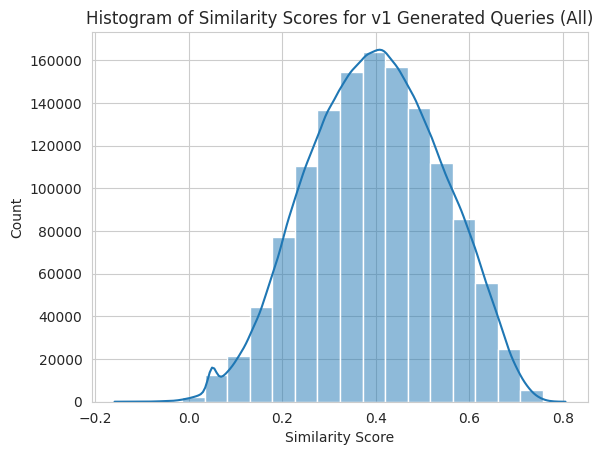

In [14]:
topn_plot(all_df1, title="Histogram of Similarity Scores for v1 Generated Queries (All)")

In [15]:
# # SECOND QUERY EXPERIMENT: key difference being 'instance of protest' vs 'collective action'. examples are also more explicit

# # trying with a different prompt: You are a reporter for a 19th century English newspaper.  Write 5 distinct, short (2-3 sentences each) fictional newspaper excerpts spanning the 1800s. Each excerpt should detail an instance of protest for a sociopolitical cause relevant to the time, and occurring at a clearly named specific location and spatial typology (e.g., 'a large assembly in Hyde Park', 'striking operatives at factory gates in Hackney', 'a demonstration on Fleet Street'). The language should sound authentic to the period.

# excerpts2 = [
#     {
#         "year": "1816",
#         "title": "Seditious Assembly Dispersed at Spa Fields",
#         "text": "A tumultuous gathering of several thousand persons assembled yesterday at Spa Fields, Islington, to hear the radical orator Mr. Henry Hunt deliver inflammatory speeches against the present administration. The meeting, ostensibly called to petition His Majesty for parliamentary reform, degenerated into scenes of the utmost disorder when a portion of the mob attempted to march upon the Tower of London with pikes and cudgels."
#     },

#     {
#         "year": "1831", 
#         "title": "Reform Riots Engulf Queen Square, Bristol",
#         "text": "The ancient city of Bristol has been thrown into a state of alarming commotion following the rejection of the Reform Bill in the House of Lords. An infuriated populace assembled in Queen Square, where they proceeded to attack the Mansion House and set fire to the Bishop's Palace, crying out 'Down with the Bishops!' The military have been called upon to restore order to the afflicted city."
#     },

#     {
#         "year": "1855",
#         "title": "Sunday Trading Riots in Hyde Park Corner", 
#         "text": "A most disgraceful scene occurred yesterday afternoon at Hyde Park Corner, where a vast multitude assembled to protest the Lord's Day Observance Bill. The crowd, estimated at upwards of 150,000 souls, pelted the carriages of the gentry with stones and refuse, compelling many fashionable persons to seek refuge in the neighbouring streets. Several constables were grievously injured in their attempts to maintain the Queen's peace."
#     },

#     {
#         "year": "1872",
#         "title": "Agricultural Labourers March Through Leamington Spa",
#         "text": "The market town of Leamington Spa witnessed an unprecedented demonstration yesterday when upwards of 30,000 agricultural labourers from across Warwickshire converged upon the Pump Room Gardens. Mr. Joseph Arch addressed the assembled multitude from the bandstand, exhorting them to form unions for the betterment of their condition and demanding wages of sixteen shillings per week."
#     },

#     {
#         "year": "1886",
#         "title": "Unemployed Demonstration Turns Violent in Trafalgar Square",
#         "text": "What commenced as a peaceable meeting of the unemployed in Trafalgar Square yesterday afternoon terminated in scenes of the most alarming description. The assembled crowd, having listened to inflammatory addresses from various socialist agitators, proceeded to march down Pall Mall, where they attacked the windows of several gentlemen's clubs with stones and iron railings torn from the neighbouring streets."
#     }
# ]


# # for each text in the excerpts generated above
# query2 = [excerpt["text"] for excerpt in excerpts2]

# # generating embeddings for query + normalising
# query2_embeddings = model.encode(query2, show_progress_bar=True, convert_to_tensor=True, normalize_embeddings=True)
# print(f"Generating vector embeddings for query2...")
# print(f"Vector array of shape {query2_embeddings.shape} obtained.")

# print(f'Calculating average excerpt embedding...')
# avg_query2_embedding = torch.mean(query2_embeddings, dim=0)
# print(f"Average vector array of shape {avg_query2_embedding.shape} obtained.")

In [16]:
# all_df2 = pd.DataFrame(util.semantic_search(avg_query2_embedding, all_embeddings, top_k=len(all_embeddings))[0])

# topn_plot(all_df2, title="Histogram of Similarity Scores for v2 Generated Queries (All)")

In [7]:
# THIRD QUERY EXPERIMENT: 
# You are a reporter for a 19th century English newspaper.  Write 5 distinct, short fictional newspaper excerpts for each decade of the 1800s, ranging from 1 sentence to a maximum of 384 tokens. Each excerpt should detail an instance of protest or resistance for a sociopolitical cause relevant to the time, and occurring at a specific named location and spatial typology (e.g., 'a large assembly in Hyde Park', 'striking operatives at factory gates in Hackney', 'a demonstration on Fleet Street'). The language should sound authentic to the period.

# so this produces 50! articles, 5 per decade. my objective is to see if a richer set of synthetic data will improve semantic matching
excerpts3 = [
    # 1800s
    {
        "year": "1801",
        "title": "Bread Riots at Smithfield Market",
        "text": "A considerable mob assembled yesterday morning at Smithfield Market, protesting the exorbitant price of bread which has risen to one shilling and fourpence per loaf."
    },
    {
        "year": "1803",
        "title": "Anti-War Meeting at Copenhagen Fields",
        "text": "Upwards of five thousand persons gathered at Copenhagen Fields yesterday evening to protest the resumption of hostilities with France, declaring the war to be contrary to the interests of the labouring classes."
    },
    {
        "year": "1805",
        "title": "Catholic Emancipation Rally in Lincoln's Inn Fields",
        "text": "A peaceable assembly of Catholics and their sympathisers convened in Lincoln's Inn Fields to petition Parliament for the removal of civil disabilities imposed upon persons of their faith."
    },
    {
        "year": "1807",
        "title": "Abolitionists Gather at Westminster Hall",
        "text": "A most respectable assembly of gentlemen and ladies congregated outside Westminster Hall to celebrate the passage of the Act for the Abolition of the Slave Trade, with Mr. Wilberforce addressing the crowd from the steps."
    },
    {
        "year": "1809",
        "title": "Framework Knitters at Nottingham Castle",
        "text": "Several hundred framework knitters assembled near Nottingham Castle expressing grievances against the introduction of wide frames, though the magistrates prevented any unlawful proceedings through the timely deployment of yeomanry."
    },

    # 1810s
    {
        "year": "1811",
        "title": "Machine Breaking at Arnold Village Green",
        "text": "The framework knitters of Arnold assembled upon the village green at midnight, proceeding thence to destroy the wide frames at Mr. Wickham's establishment, declaring such machinery to be prejudicial to their livelihood."
    },
    {
        "year": "1813",
        "title": "East India Company Protest at India House",
        "text": "A considerable crowd of merchants and free-traders assembled outside India House in Leadenhall Street, demanding an end to the East India Company's monopoly on trade with the Orient."
    },
    {
        "year": "1815",
        "title": "Corn Law Opposition at Royal Exchange",
        "text": "The merchants and traders of the City congregated at the Royal Exchange to protest the proposed Corn Laws, which they declare will raise the price of provisions and cause great distress among the manufacturing population."
    },
    {
        "year": "1816",
        "title": "Seditious Assembly at Spa Fields",
        "text": "A tumultuous gathering of several thousand persons assembled at Spa Fields, Islington, to hear the radical orator Mr. Henry Hunt deliver inflammatory speeches against the present administration. The meeting degenerated into scenes of disorder when a portion of the mob attempted to march upon the Tower of London."
    },
    {
        "year": "1819",
        "title": "Reform Meeting at St. Peter's Field, Manchester",
        "text": "An immense multitude, estimated at upwards of sixty thousand souls, assembled upon St. Peter's Field to hear Mr. Hunt and other radical speakers demand parliamentary reform and universal suffrage. The Manchester Yeomanry were called upon to disperse the crowd, resulting in several casualties among the peaceable demonstrators."
    },

    # 1820s
    {
        "year": "1820",
        "title": "Cato Street Conspiracy at Edgware Road",
        "text": "The authorities have discovered a most treasonable plot hatched in a loft above a stable in Cato Street, near Edgware Road, where a band of desperate men planned to assassinate the entire Cabinet whilst dining at Lord Harrowby's residence."
    },
    {
        "year": "1822",
        "title": "Agricultural Disturbances at Horsham Common",
        "text": "The agricultural labourers of Sussex assembled in great numbers upon Horsham Common, demanding an increase in wages and the reduction of tithes, before proceeding to destroy several threshing machines in the neighbouring parishes."
    },
    {
        "year": "1824",
        "title": "Combination Act Repeal Celebration at Crown and Anchor Tavern",
        "text": "A numerous assembly of working men gathered at the Crown and Anchor Tavern in the Strand to celebrate the repeal of the Combination Acts, with speeches delivered advocating the formation of trade societies for the protection of labour."
    },
    {
        "year": "1826",
        "title": "Power Loom Riots at Blackburn Market Square",
        "text": "The hand-loom weavers of Blackburn assembled in the market square, proceeding thence to attack the power-loom factories of Messrs. Eccles and Shorrock, declaring the machinery to be destructive of their ancient craft and means of subsistence."
    },
    {
        "year": "1829",
        "title": "Catholic Emancipation Protest at Westminster Bridge",
        "text": "A considerable crowd of Protestant gentlemen assembled upon Westminster Bridge to protest the Catholic Relief Bill, carrying banners inscribed 'No Popery' and 'The Constitution in Danger' before being dispersed by the metropolitan police."
    },

    # 1830s
    {
        "year": "1830",
        "title": "Swing Riots at Canterbury Cathedral Close",
        "text": "The agricultural labourers of East Kent assembled within Canterbury Cathedral Close, demanding the destruction of threshing machines and an increase in wages to half-a-crown per day. Several ricks were fired in the neighbouring parishes before the military could restore order."
    },
    {
        "year": "1831",
        "title": "Reform Riots at Queen Square, Bristol",
        "text": "The ancient city of Bristol has been thrown into alarming commotion following rejection of the Reform Bill in the House of Lords. An infuriated populace assembled in Queen Square, where they attacked the Mansion House and set fire to the Bishop's Palace, crying 'Down with the Bishops!' The military have been called upon to restore order."
    },
    {
        "year": "1834",
        "title": "Tolpuddle Martyrs at Dorchester Assizes",
        "text": "Six agricultural labourers from the village of Tolpuddle have been sentenced to seven years' transportation at Dorchester Assizes for administering unlawful oaths in forming a society for the advancement of wages. A considerable crowd assembled outside the courthouse to protest this harsh sentence."
    },
    {
        "year": "1836",
        "title": "Newspaper Stamp Duty Protest at Fleet Street",
        "text": "The proprietors and editors of the unstamped press assembled in Fleet Street to protest the newspaper stamp duty, which they declare to be a tax upon knowledge and prejudicial to the education of the working classes."
    },
    {
        "year": "1838",
        "title": "Chartist Meeting at Kersal Moor",
        "text": "An immense demonstration of upwards of two hundred thousand persons assembled upon Kersal Moor, near Manchester, to hear Mr. Feargus O'Connor and other Chartist leaders advocate the People's Charter and universal suffrage. The meeting proceeded with perfect order despite the vast multitude."
    },

    # 1840s
    {
        "year": "1842",
        "title": "Plug Plot Strikes at Stalybridge Mill Gates",
        "text": "The operatives of Stalybridge have withdrawn their labour and assembled at the mill gates, removing the plugs from the steam boilers to prevent the machinery from working. The strike has spread throughout the manufacturing districts of Lancashire and Yorkshire."
    },
    {
        "year": "1843",
        "title": "Anti-Corn Law Meeting at Covent Garden Theatre",
        "text": "The Anti-Corn Law League held a grand demonstration at Covent Garden Theatre, where Mr. Richard Cobden addressed a distinguished assembly of merchants and manufacturers, denouncing the bread tax as an impediment to free trade and national prosperity."
    },
    {
        "year": "1845",
        "title": "Railway Navvies Riot at Penmaenmawr Quarry",
        "text": "The railway navvies employed upon the Chester and Holyhead line have risen in violent opposition to a reduction in wages, assembling at Penmaenmawr quarry before attacking the contractor's offices and destroying several lengths of completed track."
    },
    {
        "year": "1847",
        "title": "Ten Hours Movement at Bradford Wool Exchange",
        "text": "The factory operatives of Bradford assembled outside the Wool Exchange to demand the enforcement of the Ten Hours Act, carrying banners inscribed 'Eight Hours Work, Eight Hours Rest, Eight Hours Recreation' and calling for the prosecution of mill-owners who violate the law."
    },
    {
        "year": "1848",
        "title": "Chartist Demonstration at Kennington Common",
        "text": "An immense multitude gathered upon Kennington Common to hear Mr. Feargus O'Connor address the assembled thousands regarding the People's Charter and the presentation of the National Petition to Parliament. The Metropolitan Police maintained a watchful presence as the crowd voiced demands for universal suffrage and the secret ballot."
    },

    # 1850s
    {
        "year": "1851",
        "title": "Papal Aggression Protest at Exeter Hall",
        "text": "A numerous assembly of Protestant gentlemen convened at Exeter Hall in the Strand to protest the Pope's establishment of a Catholic hierarchy in England, denouncing what they term 'Papal Aggression' and calling for the maintenance of Protestant ascendancy."
    },
    {
        "year": "1853",
        "title": "Sunday Trading Riots at Hyde Park Corner",
        "text": "A most disgraceful scene occurred at Hyde Park Corner, where a vast multitude assembled to protest the Lord's Day Observance Bill. The crowd, estimated at 150,000 souls, pelted the carriages of the gentry with stones and refuse, compelling fashionable persons to seek refuge in neighbouring streets."
    },
    {
        "year": "1855",
        "title": "Administrative Reform Meeting at Drury Lane Theatre",
        "text": "The Administrative Reform Association held a grand demonstration at Drury Lane Theatre, where speakers denounced the incompetence displayed in the conduct of the Crimean War and demanded the introduction of competitive examinations for the civil service."
    },
    {
        "year": "1857",
        "title": "Indian Mutiny Protest at Guildhall",
        "text": "The merchants and bankers of the City assembled at Guildhall to protest the Government's handling of the Indian Mutiny, demanding more vigorous measures for the suppression of the rebellion and the protection of British interests in the East."
    },
    {
        "year": "1859",
        "title": "Italian Independence Rally at St. Martin's Hall",
        "text": "A distinguished assembly of gentlemen and ladies gathered at St. Martin's Hall to express sympathy for the cause of Italian independence, with speeches delivered in support of Garibaldi and the unification of the Italian peninsula under constitutional government."
    },

    # 1860s
    {
        "year": "1862",
        "title": "Cotton Famine Meeting at Manchester Free Trade Hall",
        "text": "The cotton operatives of Manchester assembled at the Free Trade Hall to petition for relief during the present distress caused by the American Civil War, which has deprived the mills of their accustomed supply of raw cotton. Despite their sufferings, the meeting expressed support for the cause of abolition."
    },
    {
        "year": "1864",
        "title": "Garibaldi Reception at Crystal Palace",
        "text": "An enormous crowd estimated at one hundred thousand persons assembled at Crystal Palace to welcome the Italian patriot Giuseppe Garibaldi, whose visit to England has excited unprecedented enthusiasm among all classes of society sympathetic to the cause of liberty."
    },
    {
        "year": "1866",
        "title": "Reform League Demonstration at Hyde Park",
        "text": "The Reform League's intended demonstration in Hyde Park was prevented by the closing of the gates upon orders of Sir Richard Mayne. Undeterred, several thousand working men proceeded to tear down the park railings along Park Lane, declaring their right to assemble peaceably for extension of the franchise."
    },
    {
        "year": "1867",
        "title": "Fenian Rescue at Clerkenwell Prison",
        "text": "A most audacious attempt was made to rescue Fenian prisoners from Clerkenwell House of Detention by exploding a barrel of gunpowder against the prison wall. The explosion caused considerable damage to neighbouring houses and resulted in several casualties among innocent residents."
    },
    {
        "year": "1868",
        "title": "Agricultural Labourers' Union at Wellesbourne Green",
        "text": "The agricultural labourers of Warwickshire assembled upon Wellesbourne Green under an ancient chestnut tree, where Mr. Joseph Arch addressed them regarding the formation of a union for the advancement of their wages and the improvement of their condition."
    },

    # 1870s
    {
        "year": "1871",
        "title": "Paris Commune Sympathy Meeting at South Place Chapel",
        "text": "A meeting of working men was held at South Place Chapel, Finsbury, to express sympathy with the Paris Commune and to protest the bombardment of the French capital by the Versailles government."
    },
    {
        "year": "1872",
        "title": "Agricultural Labourers March at Leamington Spa",
        "text": "The market town of Leamington Spa witnessed an unprecedented demonstration when upwards of 30,000 agricultural labourers from across Warwickshire converged upon the Pump Room Gardens. Mr. Joseph Arch addressed the assembled multitude from the bandstand, demanding wages of sixteen shillings per week."
    },
    {
        "year": "1874",
        "title": "Nine Hours Movement at Newcastle Quayside",
        "text": "The engineering workers of Newcastle assembled along the quayside to demand a reduction in working hours from ten to nine per day, with no reduction in wages. The demonstration proceeded in perfect order, with speeches delivered advocating the rights of labour."
    },
    {
        "year": "1876",
        "title": "Bulgarian Atrocities Protest at St. James's Hall",
        "text": "A crowded meeting was held at St. James's Hall to protest the Turkish atrocities in Bulgaria, with Mr. Gladstone delivering a powerful address denouncing the barbarous conduct of the Ottoman authorities and calling for European intervention."
    },
    {
        "year": "1878",
        "title": "Eastern Question Rally at Trafalgar Square",
        "text": "A considerable crowd assembled in Trafalgar Square to protest the Government's foreign policy regarding the Eastern Question, with speakers denouncing Lord Beaconsfield's support for Turkey and demanding neutrality in European affairs."
    },

    # 1880s
    {
        "year": "1881",
        "title": "Irish Land League Meeting at Hyde Park",
        "text": "A vast assemblage of Irish residents and their sympathisers gathered in Hyde Park to support the Land League and protest the coercion measures proposed for Ireland, with speeches delivered advocating Home Rule and land reform."
    },
    {
        "year": "1883",
        "title": "Unemployed Demonstration at Westminster Abbey",
        "text": "A procession of unemployed working men marched to Westminster Abbey, where they attempted to present a petition to the Dean regarding the distress prevailing among the labouring classes in the metropolis."
    },
    {
        "year": "1885",
        "title": "Franchise Demonstration at Birmingham Town Hall",
        "text": "The working men of Birmingham assembled at the Town Hall to celebrate the extension of the franchise under the Reform Act, with Mr. Joseph Chamberlain addressing the crowd regarding the responsibilities of citizenship and the power of the ballot."
    },
    {
        "year": "1886",
        "title": "Unemployed Riots at Trafalgar Square",
        "text": "What commenced as a peaceable meeting of the unemployed in Trafalgar Square terminated in scenes of alarming description. The assembled crowd, having listened to inflammatory addresses from socialist agitators, proceeded to march down Pall Mall, attacking the windows of gentlemen's clubs with stones and iron railings."
    },
    {
        "year": "1888",
        "title": "Match Girls Strike at Bryant & May Factory Gates",
        "text": "The young women employed at Messrs. Bryant & May's match manufactory in Bow have withdrawn their labour in protest against the system of fines imposed upon them. Miss Annie Besant addressed the strikers at the factory gates, denouncing conditions which amount to little better than slavery."
    },
    {
        "year": "1890",
        "title": "May Day Demonstration at Hyde Park",
        "text": "The first May Day celebration in England witnessed an enormous gathering of working men and women in Hyde Park, where speakers from various trade unions addressed the assembled multitude regarding the eight-hour working day and international solidarity among the labouring classes."
    },
    {
        "year": "1892",
        "title": "Homestead Solidarity Meeting at Trafalgar Square",
        "text": "A considerable assembly of trade unionists gathered in Trafalgar Square to express sympathy with the striking steel workers at Homestead, Pennsylvania, and to protest the use of Pinkerton detectives against organised labour."
    },
    {
        "year": "1894",
        "title": "Railway Strike at St. Pancras Station",
        "text": "The railway servants employed by the Midland Railway Company assembled outside St. Pancras Station, having withdrawn their labour in sympathy with their dismissed colleagues. The strike has caused considerable disruption to passenger and goods traffic throughout the system."
    },
    {
        "year": "1896",
        "title": "Unemployed March to Westminster Palace",
        "text": "A procession of unemployed working men, estimated at several thousand, marched from the East End to the Palace of Westminster, carrying banners inscribed 'Work or Bread' and demanding that Parliament address the chronic problem of unemployment in the metropolis."
    },
    {
        "year": "1898",
        "title": "Women's Suffrage Rally at Queen's Hall",
        "text": "The National Union of Women's Suffrage Societies held a grand demonstration at Queen's Hall, where Mrs. Millicent Fawcett and other distinguished ladies addressed a crowded assembly regarding the extension of the parliamentary franchise to women of property and education."
    }
]

# embedding each text in the excerpts generated above
query3 = [excerpt["text"] for excerpt in excerpts3]

# generating embeddings for query + normalising
query3_embeddings = model.encode(query3, show_progress_bar=True, convert_to_tensor=True, normalize_embeddings=True)
print(f"Generating vector embeddings for query3...")
print(f"Vector array of shape {query3_embeddings.shape} obtained.")

print(f'Calculating average excerpt embedding...')
avg_query3_embedding = torch.mean(query3_embeddings, dim=0)
print(f"Average vector array of shape {avg_query3_embedding.shape} obtained.")

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Generating vector embeddings for query3...
Vector array of shape torch.Size([50, 768]) obtained.
Calculating average excerpt embedding...
Average vector array of shape torch.Size([768]) obtained.



Top 5 Articles:


Rank 1
Score: 0.8246
Publication: star
Article:
the foreman said that he could not possibly dispense with the company of the men at a dinner on the coronation-day, to keep them back from the demonstration on the Town Moor. Well, the dinner was provided, and the money to pay for it was afterwards taken out of the men's sick funds. (Loud cries of "Shame.") The Messrs. Cookson knew right well that the effect of the movement would be to break up all monopolies, both of manufacturers and government, and to give the small capitalist and the workman a fair chance as well as the large capitalist. The monopolies had enabled such men as them to acquire fortunes unjustly; for he maintained that it was only by injustice that princely fortunes were amassed by the employer, whilst the workman pined in rags and starvation. But things were fast verging to a crisis, he hoped that it should be a peaceful one. They were going, he was informed, to send the troops in Ireland to put down 

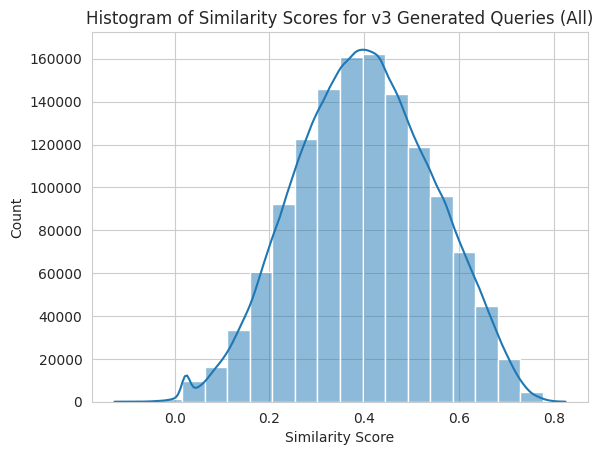

In [8]:
all_df3 = pd.DataFrame(util.semantic_search(avg_query3_embedding, all_embeddings, top_k=len(all_embeddings))[0])

topn_plot(all_df3, title="Histogram of Similarity Scores for v3 Generated Queries (All)")

In [9]:
# function to:
# 1. separating into deciles using qcut
# 2. grouping by deciles and sampling n per decile
# 3. retrieving article text, date, and source from all_articles, all_dates, and all_sources and adding it to the samples dataframe
# 4. saving to local as csv

def save_samples(df, n_quantiles=10, n_samples=10, random_state=123, file_name="file_name"):

    # folder to store samples
    samples_dir = "data/article_samples/"
    if not os.path.exists(samples_dir):
        os.makedirs(samples_dir)

    # making file path
    file_path = os.path.join(samples_dir, file_name)    

    df['decile'] = pd.qcut(df['score'], q=n_quantiles, labels=False, duplicates='drop') + 1
    # labels=False assigns integers; 
    # duplicates='drop' prevents ValueErrors arising from non-unique bin edges; 
    # +1 to make quantiles 1-10 instead of 0-9

    df_sampled = df.groupby('decile', group_keys=False).sample(n=n_samples, random_state=random_state).sort_values('decile', ascending=False)
    df_sampled['date'] = df_sampled['corpus_id'].apply(lambda idx: all_dates[idx])
    df_sampled['source'] = df_sampled['corpus_id'].apply(lambda idx: all_sources[idx])
    df_sampled['article'] = df_sampled['corpus_id'].apply(lambda idx: all_articles[idx])
    df_sampled.to_csv(file_path + '.csv', index=False, encoding="utf-8-sig")
    
    return df_sampled


In [10]:
# q1_samples = save_samples(all_df1, file_name='q1_samples')  
# q2_samples = save_samples(all_df2, file_name='q2_samples') 
q3_samples = save_samples(all_df3, file_name='q3_samples') 

trying now with example-based synthetic articles, based on the prompt (using Anthropic API): 

You are a reporter for a 19th-century English newspaper.  Write 5 distinct, short fictional newspaper excerpts spanning the 1800s and up to 384 tokens in length. Each excerpt should detail an event of collective action (e.g., a strike, a public debate, a demonstration) for a sociopolitical cause relevant to the time,  occurring at a named location and spatial typology. The language should sound authentic to the period. The following article serves as a reference: "A public conversational meeting was held on Thursday evening week, at the Ship Inn, Long Lane, Bermondsey.  Mr. SNAGS was called to the chair, and opened the proceedings by informing the assembly that it was an adjourned meeting from the previous week, and that its object was to endeavour to effect a union between the Metropolitan Reform Association and the Chartists.  Mr. MAYNARD moved the following resolution:—  "That this meeting cannot but feel, with horror and alarm, the present awful distressed state of the country, in which not only the working classes, but the manufacturers and the small capitalists, are alike upon the brink of ruin; and being convinced that the cause of this distress is class legislation, we feel assured that no permanent good will arise until the People's Charter becomes the law of the land, which would soon be accomplished by an honest union of the middle and working classes directing their energies for this great object."  

In [22]:
excerpts_eg = [
    {
        "year": "1812",
        "title": "Framework Knitters Assemble at Nottingham Market Cross",
        "text": "A numerous body of framework knitters assembled yesterday evening at the Market Cross in this town, expressing their determined opposition to the introduction of cut-up stockings and wide frames. Mr. HOLLINGSWORTH, a respectable hosier, addressed the crowd from the steps of the Exchange, declaring that such innovations would reduce the ancient craft to mere machine-tending and deprive honest workmen of their livelihood. The assembly passed a resolution to petition Parliament for the regulation of the hosiery trade, and appointed a committee to correspond with similar bodies in Leicester and Derby. The proceedings concluded with perfect order, though the magistrates maintained a watchful presence throughout."
    },
    
    {
        "year": "1831", 
        "title": "Political Union Convenes at Birmingham Town Hall",
        "text": "The Birmingham Political Union held its monthly meeting on Tuesday last at the Town Hall, with Mr. THOMAS ATTWOOD presiding over an assembly of upwards of three thousand persons. The chairman delivered a powerful address upon the necessity of parliamentary reform, declaring that the present system of representation was wholly inadequate to the wants of a commercial and manufacturing nation. Mr. JOSHUA SCHOLEFIELD moved a resolution condemning the rejection of Lord Russell's Reform Bill by the House of Lords, which was carried with acclamation. The meeting resolved to petition His Majesty to create sufficient peers to ensure the passage of the measure, and appointed delegates to attend the National Political Union in London. The proceedings were conducted with the utmost respectability and order."
    },
    
    {
        "year": "1848",
        "title": "Chartist Convention at John Street Institution",
        "text": "The National Convention of the Chartist body commenced its sittings yesterday at the John Street Institution, Fitzroy Square, with delegates present from all the principal manufacturing districts. Mr. FEARGUS O'CONNOR was unanimously elected president, and in his opening address declared that the time had arrived when the working classes must assert their constitutional rights through peaceful but determined action. The Convention resolved to present the National Petition, bearing upwards of five million signatures, to the House of Commons, and appointed a committee to arrange for a grand demonstration upon Kennington Common. Mr. ERNEST JONES moved that should Parliament reject their just demands, the people would be justified in withdrawing their labour until the Charter became law. The debate upon this resolution continues today."
    },
    
    {
        "year": "1866",
        "title": "Reform Demonstration at Trafalgar Square",
        "text": "A vast assemblage of working men gathered yesterday afternoon in Trafalgar Square to demand the extension of the parliamentary franchise, under the auspices of the Reform League. Mr. EDMOND BEALES, the president, addressed the multitude from the steps of the National Gallery, declaring that taxation without representation was tyranny whether imposed by King Charles or Lord Derby's administration. The crowd, estimated at fifty thousand persons, carried banners inscribed with 'The Bill, the Whole Bill, and Nothing but the Bill' and 'No Surrender to the House of Lords.' Resolutions were passed condemning the Government's limited Reform Bill and demanding household suffrage for all ratepayers. The demonstration concluded with the singing of the National Anthem, though a considerable body proceeded afterwards to Hyde Park despite the prohibition of the authorities."
    },
    
    {
        "year": "1888",
        "title": "Dock Labourers Strike Committee at Wade's Arms",
        "text": "The strike committee of the dock labourers held an important meeting last evening at Wade's Arms public house, Jeremiah Street, Poplar, to consider the employers' latest proposals regarding wages and conditions. Mr. BEN TILLETT, the secretary of the Tea Operatives and General Labourers' Union, informed the assembly that the dock companies had offered to increase the rate to sixpence per hour, but refused to guarantee the 'dockers' tanner' or to recognise the union. After considerable debate, the meeting unanimously resolved to reject these terms and to continue the strike until their full demands were conceded. Mr. JOHN BURNS addressed the gathering, declaring that the solidarity shown by workers throughout London proved that the age of sweated labour was drawing to a close. Collections were announced for the relief of strikers' families, and pickets were organised for all the principal dock gates."
    }
]

# embedding each text in the excerpts generated above
query_eg = [excerpt["text"] for excerpt in excerpts_eg]

# generating embeddings for query + normalising
query_eg_embeddings = model.encode(query_eg, show_progress_bar=True, convert_to_tensor=True, normalize_embeddings=True)
print(f"Generating vector embeddings for example-based queries...")
print(f"Vector array of shape {query_eg_embeddings.shape} obtained.")

print(f'Calculating average excerpt embedding...')
avg_query_eg_embedding = torch.mean(query_eg_embeddings, dim=0)
print(f"Average vector array of shape {avg_query_eg_embedding.shape} obtained.")


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating vector embeddings for example-based queries...
Vector array of shape torch.Size([5, 768]) obtained.
Calculating average excerpt embedding...
Average vector array of shape torch.Size([768]) obtained.



Top 5 Articles:


Rank 1
Score: 0.8931
Publication: star
Article:
among the wretched thralls of labour, hero is vision that might satisfy the highest aspirations of most ambitions, if no worthier motive could men to action.  We believe, we know, that the working classes really are prepared and waiting to be led to well-considered and rational movement to utter pauperism be arrested.  In addition to the adhesion of the Bobbin Turners of Essexwich, and further applications from several classes of Boiler Makers, the Central Committee this week, received the most gratifying assiances of support to enable them to meet the very prosecutions. We believe we shall come out we order unscathed in person and in honour, that the cause of National Labour Union will have a renewed impetus from our persecution. 9, Tottenham-court-road. Wm. PEXL, Sec.  NORTHWESTERN FINANCIAL AND PARLIAMENTARY REFORM ASSOCIATION.  On Thursday night a meeting of the Manchester Financial and Parliamentary Reform Associat

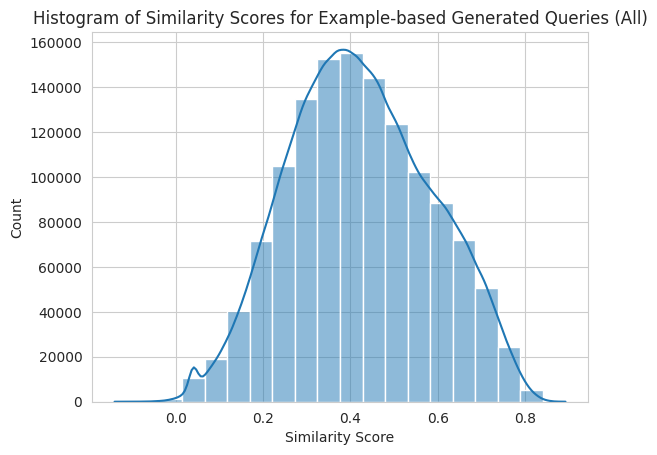

In [ ]:
#eda

all_df_eg = pd.DataFrame(util.semantic_search(avg_query_eg_embedding, all_embeddings, top_k=len(all_embeddings))[0])

topn_plot(all_df_eg, title="Histogram of Similarity Scores for Example-based Generated Queries (All)")

In [26]:
eg_samples = save_samples(all_df_eg, file_name='eg_based_samples') 